### Imports

In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

from dataclasses import dataclass
from collections import defaultdict

### Global Configuration

In [15]:
#ENV_NAME = "CliffWalking-v0" I tried this version but it gave me the error : DeprecatedEnv: Environment version v0 for `CliffWalking` is deprecated. Please use `CliffWalking-v1` instead.
ENV_NAME = "CliffWalking-v1"

N_ROWS = 4
N_COLS = 12

N_STATES = N_ROWS * N_COLS
N_ACTIONS = 4

ACTION_SYMBOLS = {
    0: "↑",
    1: "→",
    2: "↓",
    3: "←"
}

ACTION_DELTAS = {
    0 : (-1, 0),
    1 : (0, 1),
    2 : (1, 0),
    3 : (0, -1)
}

START_STATE = 36
GOAL_STATE = 47

CLIFF_STATES = set(range(37, 47))


### Helper Functions

In [16]:
def state_to_pos(state):
    row = state // N_COLS
    col = state % N_COLS
    return row, col

def pos_to_state(row, col):
    return row * N_COLS + col

def is_valid_pos(row, col):
    return 0 <= row < N_ROWS and 0 <= col < N_COLS

### Epsilon Schedules

In [17]:
def constant_epsilon(epsilon_value):
    def schedule(episode):
        return epsilon_value
    return schedule

def linear_decay_epsilon(start = 1.0, end = 0.05, decay_episodes=500):
    def schedule(episode):
        fraction = min(episode / decay_episodes, 1.0)
        return start + fraction * (end - start)
    return schedule

def exponential_decay_epsilon(start = 1.0, end = 0.05, decay_rate = 0.995):
    def schedule(episode):
        return max(end, start * (decay_rate ** episode))
    return schedule

### Epsilon Greedy Action Selection and Training Configuration

In [18]:
def epsilon_greedy_action(Q,state,epsilon, rng):
    if rng.random() < epsilon:
        return rng.choice(N_ACTIONS)
    return int(np.argmax(Q[state]))

In [19]:
@dataclass
class TDConfig:
    algorithm: str
    alpha: float = 0.5
    gamma: float = 1.0
    num_episodes: int = 500
    max_steps_per_episode: int = 10_000
    epsilon_schedule: callable = constant_epsilon(0.1)
    seed: int = 42

### SARSA Training

In [20]:
def train_sarsa(config):
    env = gym.make(ENV_NAME)
    env.reset(seed=config.seed)

    rng = np.random.default_rng(config.seed)

    Q = np.zeros((N_STATES, N_ACTIONS), dtype=np.float64)

    episode_rewards = np.zeros(config.num_episodes, dtype=np.float64)
    episode_lengths = np.zeros(config.num_episodes, dtype=np.int64)

    for episode in range(config.num_episodes):
        epsilon = config.epsilon_schedule(episode)

        state, info = env.reset(seed=config.seed + episode)

        action = epsilon_greedy_action(Q, state, epsilon, rng)

        total_reward = 0.0

        for step in range(config.max_steps_per_episode):
            next_state, reward, terminated, truncated, info = env.step(action)

            total_reward += reward

            if terminated:
                td_target = reward
                td_error = td_target - Q[state, action]
                Q[state, action] += config.alpha * td_error
                break

            next_action = epsilon_greedy_action(Q, next_state, epsilon, rng)

            td_target = reward + config.gamma * Q[next_state, next_action]
            td_error = td_target - Q[state, action]

            Q[state, action] += config.alpha * td_error

            state = next_state
            action = next_action

            if truncated:
                break

        episode_rewards[episode] = total_reward
        episode_lengths[episode] = step + 1

    env.close()

    return Q, episode_rewards, episode_lengths

### Q-Learning Training

In [21]:
def train_q_learning(config):
    env = gym.make(ENV_NAME)
    env.reset(seed=config.seed)

    rng = np.random.default_rng(config.seed)

    Q = np.zeros((N_STATES, N_ACTIONS), dtype=np.float64)

    episode_rewards = np.zeros(config.num_episodes, dtype=np.float64)
    episode_lengths = np.zeros(config.num_episodes, dtype=np.int64)

    for episode in range(config.num_episodes):
        epsilon = config.epsilon_schedule(episode)

        state, info = env.reset(seed=config.seed + episode)

        total_reward = 0.0

        for step in range(config.max_steps_per_episode):
            action = epsilon_greedy_action(Q, state, epsilon, rng)

            next_state, reward, terminated, truncated, info = env.step(action)

            total_reward += reward

            if terminated:
                td_target = reward
            else:
                td_target = reward + config.gamma * np.max(Q[next_state])

            td_error = td_target - Q[state, action]
            Q[state, action] += config.alpha * td_error

            state = next_state

            if terminated or truncated:
                break

        episode_rewards[episode] = total_reward
        episode_lengths[episode] = step + 1

    env.close()

    return Q, episode_rewards, episode_lengths

### Multi Seed Experiment Runner

In [22]:
def run_multi_seed_experiment(
    algorithm,
    alpha=0.5,
    gamma=1.0,
    num_episodes=500,
    epsilon_schedule=constant_epsilon(0.1),
    seeds=None
):
    if seeds is None:
        seeds = np.arange(30)

    all_rewards = []
    all_lengths = []
    all_Q = []

    for seed in seeds:
        config = TDConfig(
            algorithm=algorithm,
            alpha=alpha,
            gamma=gamma,
            num_episodes=num_episodes,
            epsilon_schedule=epsilon_schedule,
            seed=int(seed)
        )

        if algorithm.lower() == "sarsa":
            Q, rewards, lengths = train_sarsa(config)
        elif algorithm.lower() in ["q_learning", "q-learning", "qlearning"]:
            Q, rewards, lengths = train_q_learning(config)
        else:
            raise ValueError("algorithm must be 'sarsa' or 'q_learning'")

        all_rewards.append(rewards)
        all_lengths.append(lengths)
        all_Q.append(Q)

    return {
        "algorithm": algorithm,
        "alpha": alpha,
        "gamma": gamma,
        "num_episodes": num_episodes,
        "epsilon_schedule": epsilon_schedule,
        "seeds": np.array(seeds),
        "rewards": np.array(all_rewards),
        "lengths": np.array(all_lengths),
        "Q_tables": np.array(all_Q)
    }

### Confidence Interval Utilities

In [23]:
def mean_and_95_ci(data):
    data = np.asarray(data, dtype=np.float64)

    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0, ddof=1)
    n = data.shape[0]

    ci = 1.96 * std / np.sqrt(n)

    return mean, ci

def moving_average_1d(data, window_size = 10):
    if window_size <= 1:
        return data

    kernel = np.ones(window_size) / window_size
    return np.convolve(data, kernel, mode="valid")

def smooth_mean_ci(mean, ci, window_size = 10):
    if window_size <= 1:
        return mean, ci, np.arange(len(mean))

    mean_smooth = moving_average_1d(mean, window_size)
    ci_smooth = moving_average_1d(ci, window_size)
    x = np.arange(len(mean_smooth)) + window_size - 1

    return mean_smooth, ci_smooth, x

### Sarsa VS Q-learning

In [24]:
SEEDS = np.arange(30)
NUM_EPISODES = 500

main_epsilon_schedule = constant_epsilon(0.1)

sarsa_result = run_multi_seed_experiment(
    algorithm="sarsa",
    alpha=0.5,
    gamma=1.0,
    num_episodes=NUM_EPISODES,
    epsilon_schedule=main_epsilon_schedule,
    seeds=SEEDS
)

q_learning_result = run_multi_seed_experiment(
    algorithm="q_learning",
    alpha=0.5,
    gamma=1.0,
    num_episodes=NUM_EPISODES,
    epsilon_schedule=main_epsilon_schedule,
    seeds=SEEDS
)

print(sarsa_result)
print(q_learning_result)

{'algorithm': 'sarsa', 'alpha': 0.5, 'gamma': 1.0, 'num_episodes': 500, 'epsilon_schedule': <function constant_epsilon.<locals>.schedule at 0x000002016ECE45E0>, 'seeds': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]), 'rewards': array([[  -66., -2058.,  -125., ...,   -19.,   -19.,   -20.],
       [ -105., -1924.,  -411., ...,   -27.,   -24.,   -21.],
       [  -77., -1733.,   -98., ...,   -17.,   -17.,   -17.],
       ...,
       [-1700.,  -385.,   -44., ...,   -18.,   -19.,   -17.],
       [ -888., -1179.,  -111., ...,   -17.,   -21.,   -50.],
       [-1924.,  -367.,   -58., ...,   -17.,   -17.,   -22.]],
      shape=(30, 500)), 'lengths': array([[ 66, 573, 125, ...,  19,  19,  20],
       [105, 538, 213, ...,  27,  24,  21],
       [ 77, 545,  98, ...,  17,  17,  17],
       ...,
       [512, 187,  44, ...,  18,  19,  17],
       [294, 387, 111, ...,  17,  21,  50],
       [538, 169,  58, ...,  17

### Plotting Learning Curves with 95% Confidence Intervals

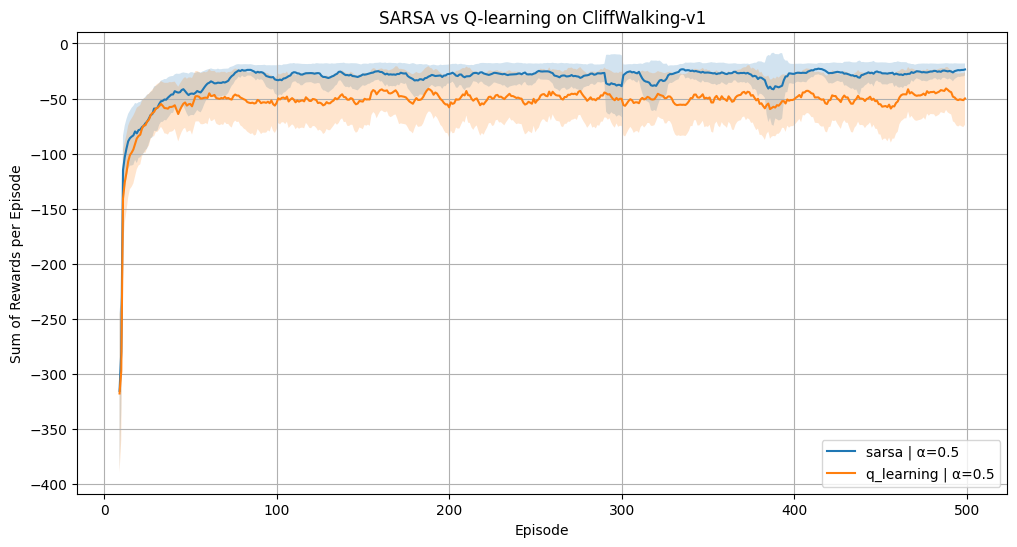

In [26]:
def plot_learning_curves_with_ci(results, window_size=10, title="Learning Curves"):
    plt.figure(figsize=(12, 6))

    for result in results:
        rewards = result["rewards"]
        mean, ci = mean_and_95_ci(rewards)

        mean_smooth, ci_smooth, x = smooth_mean_ci(mean, ci, window_size)

        label = f"{result['algorithm']} | α={result['alpha']}"

        plt.plot(x, mean_smooth, label=label)
        plt.fill_between(
            x,
            mean_smooth - ci_smooth,
            mean_smooth + ci_smooth,
            alpha=0.2
        )

    plt.title(title)
    plt.xlabel("Episode")
    plt.ylabel("Sum of Rewards per Episode")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_learning_curves_with_ci(
    [sarsa_result, q_learning_result],
    window_size=10,
    title="SARSA vs Q-learning on CliffWalking-v1"
)

### Average Q-table Across Seeds

In [28]:
def average_Q_across_seeds(result):

    return np.mean(result["Q_tables"], axis=0)


Q_sarsa_avg = average_Q_across_seeds(sarsa_result)
Q_q_learning_avg = average_Q_across_seeds(q_learning_result)
print(Q_sarsa_avg)
print(Q_q_learning_avg)

[[ -21.81402095  -18.88172303  -22.60610484  -21.46316167]
 [ -20.26848212  -16.93120838  -21.22028949  -21.52936942]
 [ -19.08319067  -15.19997772  -20.55857534  -20.03741437]
 [ -17.77635622  -14.25649132  -18.956995    -18.94524644]
 [ -16.95468212  -13.89403846  -17.74279432  -17.8440786 ]
 [ -15.17238004  -11.95134718  -17.00702544  -16.84424294]
 [ -13.39719838  -10.27585895  -14.73304172  -15.32357821]
 [ -13.01409445   -8.97873157  -13.66632519  -14.28381897]
 [ -10.56692195   -7.25421141  -12.59288891  -13.35888455]
 [  -9.51121444   -6.5168145    -9.81239312  -11.58982677]
 [  -8.40176364   -6.18171713   -7.78763356   -9.70485381]
 [  -7.27065105   -6.88389216   -4.47666894   -8.62562188]
 [ -20.98348756  -20.07793216  -24.47191183  -22.42008932]
 [ -18.74666184  -23.22960092  -26.43022     -22.25780438]
 [ -18.69558399  -22.44189678  -27.81434287  -21.77968667]
 [ -18.24112723  -19.53934148  -24.46181326  -19.82846291]
 [ -16.42444038  -18.419427    -23.08718055  -19.0269436

### Greedy Policy and Value Functions

In [30]:
def greedy_policy_from_Q(Q):
    return np.argmax(Q, axis=1)


def value_function_from_Q(Q):

    return np.max(Q, axis=1)


policy_sarsa = greedy_policy_from_Q(Q_sarsa_avg)
policy_q_learning = greedy_policy_from_Q(Q_q_learning_avg)

V_sarsa = value_function_from_Q(Q_sarsa_avg)
V_q_learning = value_function_from_Q(Q_q_learning_avg)

### Learned Q values  as Arrows in Grid

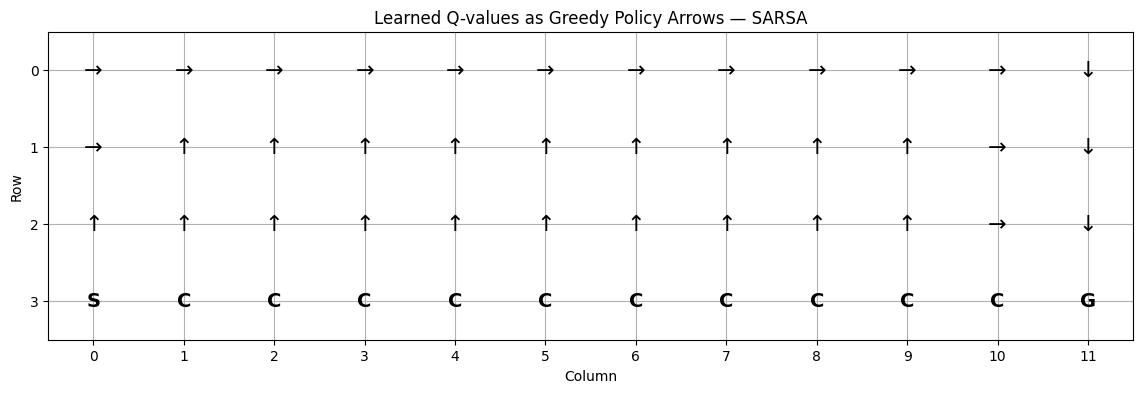

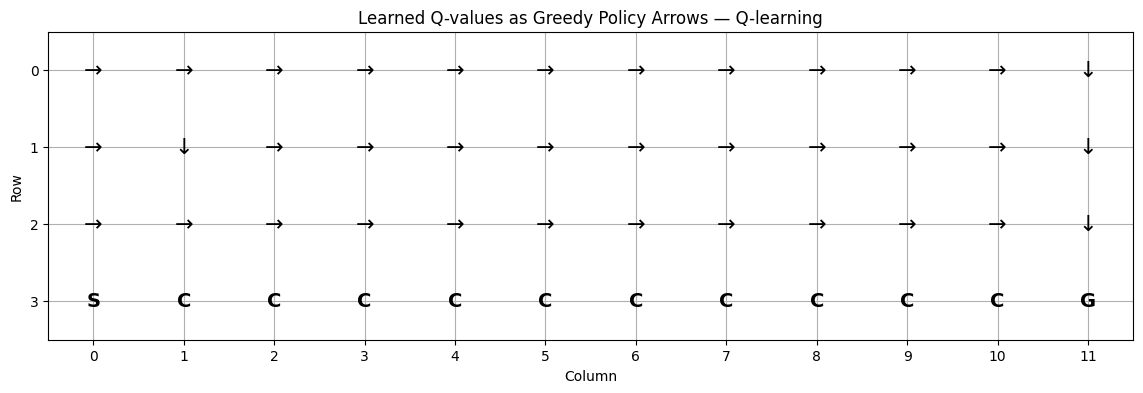

In [31]:
def plot_policy_arrows(Q, title):
    policy = greedy_policy_from_Q(Q)

    fig, ax = plt.subplots(figsize=(14, 4))

    ax.set_title(title)
    ax.set_xlim(-0.5, N_COLS - 0.5)
    ax.set_ylim(N_ROWS - 0.5, -0.5)

    ax.set_xticks(np.arange(N_COLS))
    ax.set_yticks(np.arange(N_ROWS))
    ax.grid(True)

    for state in range(N_STATES):
        row, col = state_to_pos(state)

        if state == START_STATE:
            ax.text(col, row, "S", ha="center", va="center", fontsize=14, fontweight="bold")
        elif state == GOAL_STATE:
            ax.text(col, row, "G", ha="center", va="center", fontsize=14, fontweight="bold")
        elif state in CLIFF_STATES:
            ax.text(col, row, "C", ha="center", va="center", fontsize=14, fontweight="bold")
        else:
            action = policy[state]
            ax.text(col, row, ACTION_SYMBOLS[action], ha="center", va="center", fontsize=16)

    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    plt.show()


plot_policy_arrows(
    Q_sarsa_avg,
    title="Learned Q-values as Greedy Policy Arrows — SARSA"
)

plot_policy_arrows(
    Q_q_learning_avg,
    title="Learned Q-values as Greedy Policy Arrows — Q-learning"
)

### Value Function Heatmaps

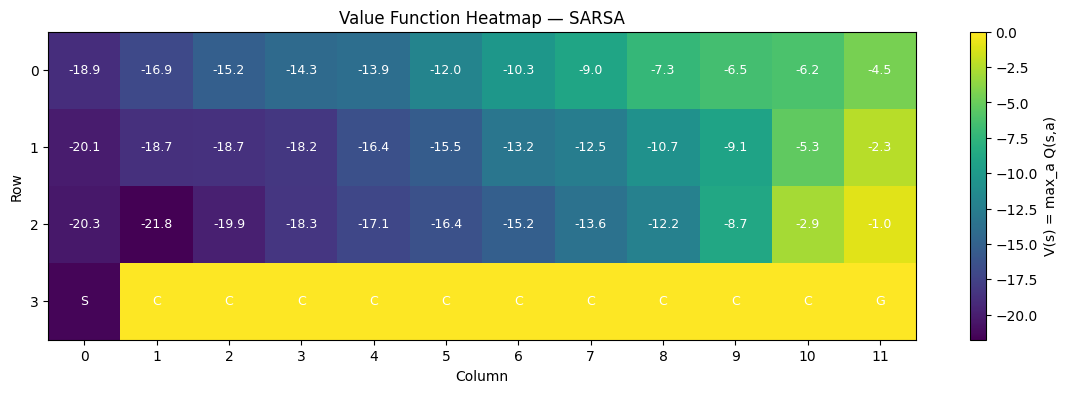

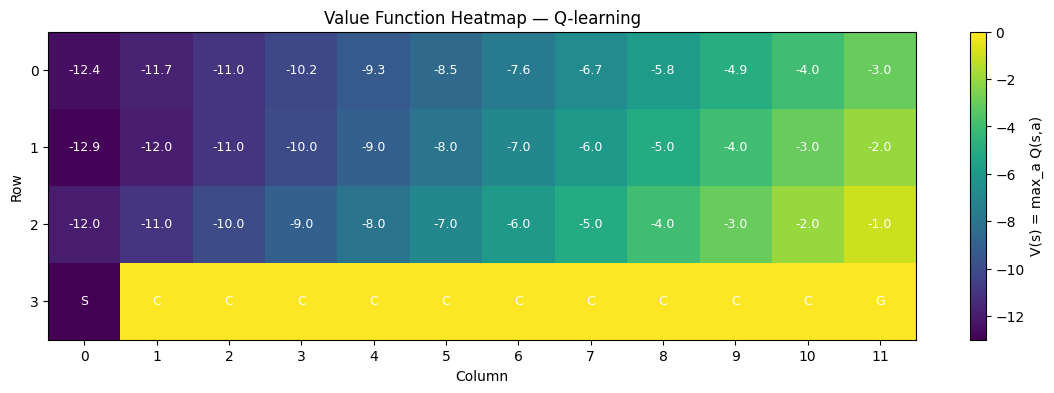

In [32]:
def plot_value_heatmap(Q, title):
    V = value_function_from_Q(Q)
    V_grid = V.reshape(N_ROWS, N_COLS)

    masked_grid = V_grid.copy()

    fig, ax = plt.subplots(figsize=(14, 4))

    im = ax.imshow(masked_grid, aspect="auto")

    ax.set_title(title)
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")

    ax.set_xticks(np.arange(N_COLS))
    ax.set_yticks(np.arange(N_ROWS))

    for state in range(N_STATES):
        row, col = state_to_pos(state)

        if state == START_STATE:
            label = "S"
        elif state == GOAL_STATE:
            label = "G"
        elif state in CLIFF_STATES:
            label = "C"
        else:
            label = f"{V_grid[row, col]:.1f}"

        ax.text(col, row, label, ha="center", va="center", color="white", fontsize=9)

    plt.colorbar(im, ax=ax, label="V(s) = max_a Q(s,a)")
    plt.show()


plot_value_heatmap(
    Q_sarsa_avg,
    title="Value Function Heatmap — SARSA"
)

plot_value_heatmap(
    Q_q_learning_avg,
    title="Value Function Heatmap — Q-learning"
)

### Generating and Plotting Sample Trajectory From Learned Policy

In [33]:
def generate_greedy_trajectory(Q, max_steps=100):
    env = gym.make(ENV_NAME)

    state, info = env.reset()

    trajectory = [state]
    total_reward = 0.0

    for step in range(max_steps):
        action = int(np.argmax(Q[state]))

        next_state, reward, terminated, truncated, info = env.step(action)

        trajectory.append(next_state)
        total_reward += reward

        state = next_state

        if terminated or truncated:
            break

    env.close()

    return trajectory, total_reward

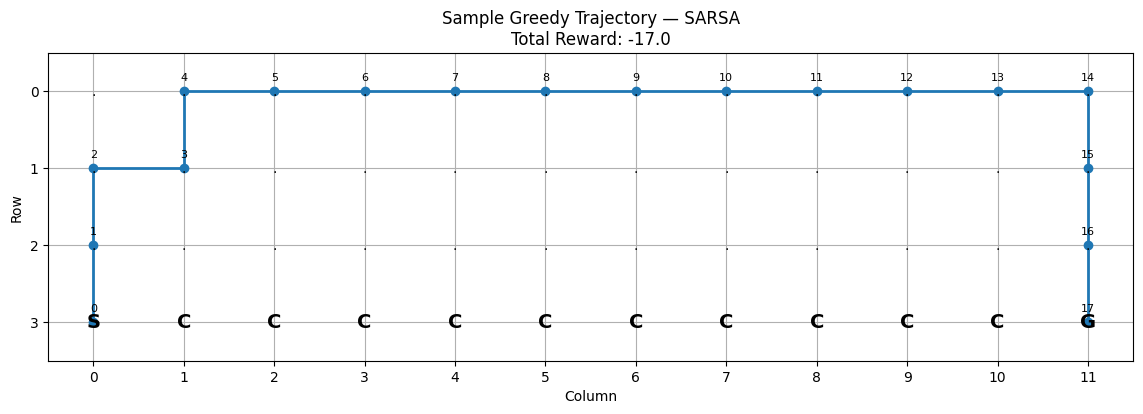

Trajectory states: [36, 24, 12, 13, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 23, 35, 47]
Total reward: -17.0


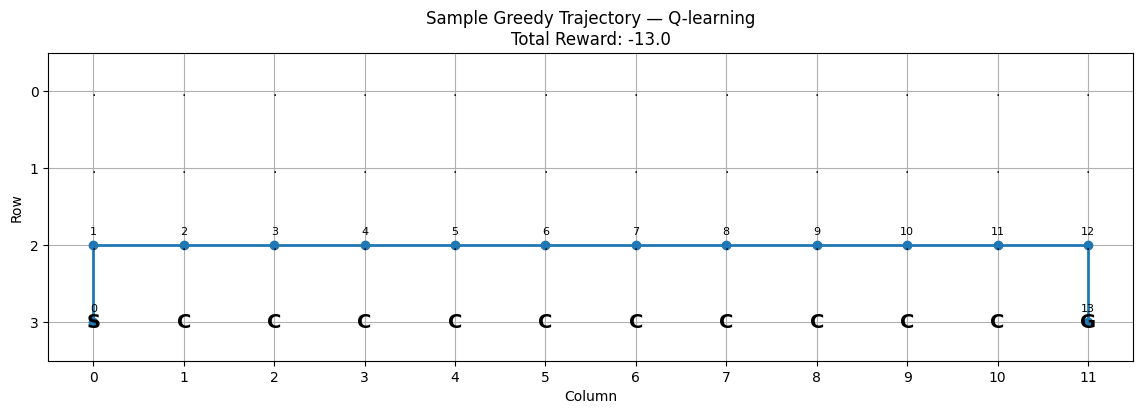

Trajectory states: [36, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 47]
Total reward: -13.0


In [34]:
def plot_sample_trajectory(Q, title):
    trajectory, total_reward = generate_greedy_trajectory(Q)

    fig, ax = plt.subplots(figsize=(14, 4))

    ax.set_title(f"{title}\nTotal Reward: {total_reward}")
    ax.set_xlim(-0.5, N_COLS - 0.5)
    ax.set_ylim(N_ROWS - 0.5, -0.5)

    ax.set_xticks(np.arange(N_COLS))
    ax.set_yticks(np.arange(N_ROWS))
    ax.grid(True)

    for state in range(N_STATES):
        row, col = state_to_pos(state)

        if state == START_STATE:
            ax.text(col, row, "S", ha="center", va="center", fontsize=14, fontweight="bold")
        elif state == GOAL_STATE:
            ax.text(col, row, "G", ha="center", va="center", fontsize=14, fontweight="bold")
        elif state in CLIFF_STATES:
            ax.text(col, row, "C", ha="center", va="center", fontsize=14, fontweight="bold")
        else:
            ax.text(col, row, ".", ha="center", va="center", fontsize=10)

    trajectory_positions = np.array([state_to_pos(s) for s in trajectory])
    rows = trajectory_positions[:, 0]
    cols = trajectory_positions[:, 1]

    ax.plot(cols, rows, marker="o", linewidth=2)

    for idx, state in enumerate(trajectory):
        row, col = state_to_pos(state)
        ax.text(col, row - 0.18, str(idx), ha="center", va="center", fontsize=8)

    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    plt.show()

    print("Trajectory states:", trajectory)
    print("Total reward:", total_reward)


plot_sample_trajectory(
    Q_sarsa_avg,
    title="Sample Greedy Trajectory — SARSA"
)

plot_sample_trajectory(
    Q_q_learning_avg,
    title="Sample Greedy Trajectory — Q-learning"
)

### Alpha Experiments

In [35]:
alpha_values = [0.1, 0.3, 0.5, 0.7, 0.9]

alpha_experiment_results = []

for alpha in alpha_values:
    print(f"Running SARSA alpha={alpha}")

    result_sarsa_alpha = run_multi_seed_experiment(
        algorithm="sarsa",
        alpha=alpha,
        gamma=1.0,
        num_episodes=NUM_EPISODES,
        epsilon_schedule=constant_epsilon(0.1),
        seeds=SEEDS
    )

    alpha_experiment_results.append(result_sarsa_alpha)

    print(f"Running Q-learning alpha={alpha}")

    result_q_alpha = run_multi_seed_experiment(
        algorithm="q_learning",
        alpha=alpha,
        gamma=1.0,
        num_episodes=NUM_EPISODES,
        epsilon_schedule=constant_epsilon(0.1),
        seeds=SEEDS
    )

    alpha_experiment_results.append(result_q_alpha)

Running SARSA alpha=0.1
Running Q-learning alpha=0.1
Running SARSA alpha=0.3
Running Q-learning alpha=0.3
Running SARSA alpha=0.5
Running Q-learning alpha=0.5
Running SARSA alpha=0.7
Running Q-learning alpha=0.7
Running SARSA alpha=0.9
Running Q-learning alpha=0.9


### Plotting Alpha Experiments Learning Curves

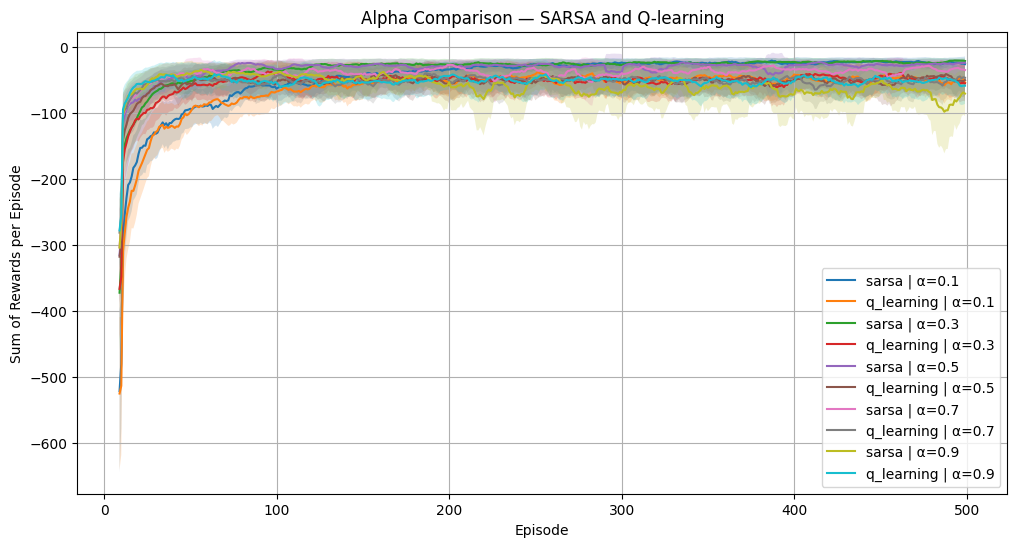

In [36]:
plot_learning_curves_with_ci(
    alpha_experiment_results,
    window_size=10,
    title="Alpha Comparison — SARSA and Q-learning"
)

### Epsilon Decay Experiments

In [38]:
epsilon_schedule_experiments = {
    "constant_0.1": constant_epsilon(0.1),
    "linear_1.0_to_0.05": linear_decay_epsilon(start=1.0, end=0.05, decay_episodes=NUM_EPISODES),
    "exponential_1.0_to_0.05": exponential_decay_epsilon(start=1.0, end=0.05, decay_rate=0.99),
}

epsilon_experiment_results = []

for schedule_name, schedule_fn in epsilon_schedule_experiments.items():
    print(f"Running SARSA schedule={schedule_name}")

    result_sarsa_eps = run_multi_seed_experiment(
        algorithm=f"sarsa",
        alpha=0.5,
        gamma=1.0,
        num_episodes=NUM_EPISODES,
        epsilon_schedule=schedule_fn,
        seeds=SEEDS
    )

    epsilon_experiment_results.append(result_sarsa_eps)

    print(f"Running Q-learning schedule={schedule_name}")

    result_q_eps = run_multi_seed_experiment(
        algorithm=f"q_learning",
        alpha=0.5,
        gamma=1.0,
        num_episodes=NUM_EPISODES,
        epsilon_schedule=schedule_fn,
        seeds=SEEDS
    )

    epsilon_experiment_results.append(result_q_eps)

Running SARSA schedule=constant_0.1
Running Q-learning schedule=constant_0.1
Running SARSA schedule=linear_1.0_to_0.05
Running Q-learning schedule=linear_1.0_to_0.05
Running SARSA schedule=exponential_1.0_to_0.05
Running Q-learning schedule=exponential_1.0_to_0.05


### Plotting the Epsilon Decay Experiment Learning Curves

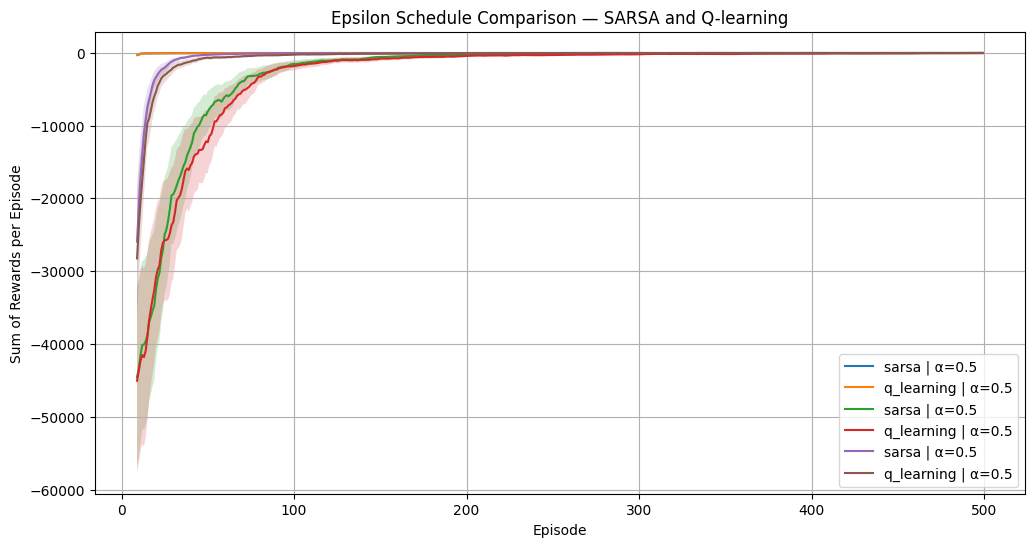

In [39]:
plot_learning_curves_with_ci(
    epsilon_experiment_results,
    window_size=10,
    title="Epsilon Schedule Comparison — SARSA and Q-learning"
)

### Plotting Epsilon Schedules

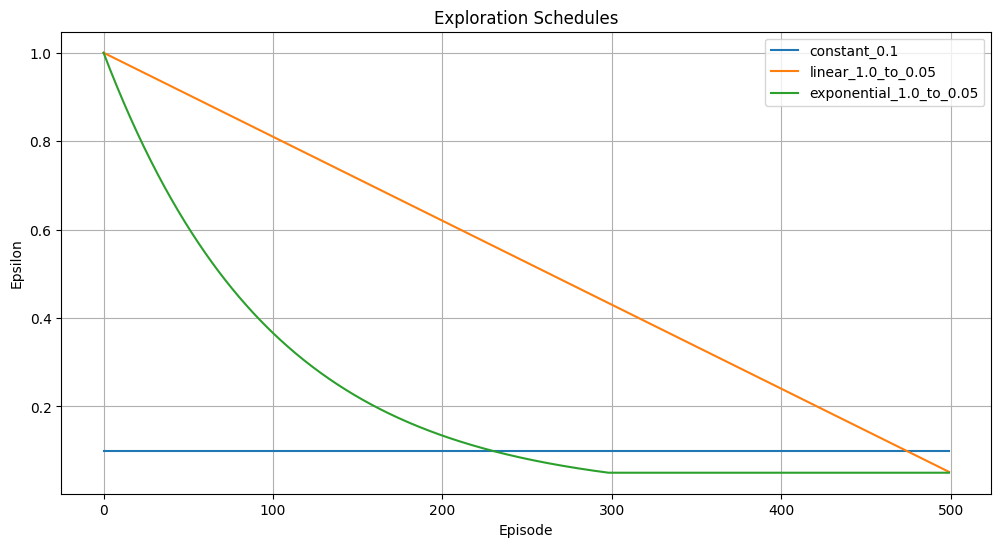

In [40]:
def plot_epsilon_schedules(schedule_dict, num_episodes):

    plt.figure(figsize=(12, 6))

    episodes = np.arange(num_episodes)

    for name, schedule in schedule_dict.items():
        eps_values = np.array([schedule(ep) for ep in episodes])
        plt.plot(episodes, eps_values, label=name)

    plt.title("Exploration Schedules")
    plt.xlabel("Episode")
    plt.ylabel("Epsilon")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_epsilon_schedules(
    epsilon_schedule_experiments,
    NUM_EPISODES
)

### Evaluating the Greedy Policy

In [41]:
def evaluate_greedy_policy(Q, num_eval_episodes=100, seed=123):

    env = gym.make(ENV_NAME)
    rng = np.random.default_rng(seed)

    rewards = np.zeros(num_eval_episodes, dtype=np.float64)
    lengths = np.zeros(num_eval_episodes, dtype=np.int64)

    for episode in range(num_eval_episodes):
        state, info = env.reset(seed=seed + episode)

        total_reward = 0.0

        for step in range(10_000):
            action = int(np.argmax(Q[state]))

            next_state, reward, terminated, truncated, info = env.step(action)

            total_reward += reward
            state = next_state

            if terminated or truncated:
                break

        rewards[episode] = total_reward
        lengths[episode] = step + 1

    env.close()

    return {
        "mean_reward": np.mean(rewards),
        "std_reward": np.std(rewards, ddof=1),
        "mean_length": np.mean(lengths),
        "std_length": np.std(lengths, ddof=1),
        "rewards": rewards,
        "lengths": lengths
    }

### Learning Speed and Sample Efficiency Metrics

In [42]:
def compute_learning_metrics(result, threshold=-20, final_window=50):
    rewards = result["rewards"]

    mean_rewards, ci = mean_and_95_ci(rewards)

    final_performance = np.mean(mean_rewards[-final_window:])

    threshold_episode = None

    for episode_idx, reward_value in enumerate(mean_rewards):
        if reward_value >= threshold:
            threshold_episode = episode_idx
            break

    if threshold_episode is None:
        threshold_episode = np.nan

    auc = np.sum(mean_rewards)

    return {
        "final_avg_reward": final_performance,
        "episode_reaches_threshold": threshold_episode,
        "reward_auc": auc,
        "mean_episode_length_final": np.mean(result["lengths"][:, -final_window:])
    }

### Comparison Table

In [43]:
def create_comparison_table(results, threshold=-20, final_window=50):
    rows = []

    for result in results:
        Q_avg = average_Q_across_seeds(result)
        eval_stats = evaluate_greedy_policy(Q_avg)

        metrics = compute_learning_metrics(
            result,
            threshold=threshold,
            final_window=final_window
        )

        row = {
            "Algorithm": result["algorithm"],
            "Alpha": result["alpha"],
            "Final Avg Train Reward": metrics["final_avg_reward"],
            "Eval Mean Reward": eval_stats["mean_reward"],
            "Eval Mean Length": eval_stats["mean_length"],
            "Episode Reaches Threshold": metrics["episode_reaches_threshold"],
            "Reward AUC": metrics["reward_auc"],
            "Final Mean Episode Length": metrics["mean_episode_length_final"]
        }

        rows.append(row)

    return rows


comparison_rows = create_comparison_table(
    [sarsa_result, q_learning_result],
    threshold=-20,
    final_window=50
)

comparison_rows

[{'Algorithm': 'sarsa',
  'Alpha': 0.5,
  'Final Avg Train Reward': np.float64(-25.72533333333333),
  'Eval Mean Reward': np.float64(-17.0),
  'Eval Mean Length': np.float64(17.0),
  'Episode Reaches Threshold': 102,
  'Reward AUC': np.float64(-18381.833333333336),
  'Final Mean Episode Length': np.float64(21.765333333333334)},
 {'Algorithm': 'q_learning',
  'Alpha': 0.5,
  'Final Avg Train Reward': np.float64(-47.14066666666667),
  'Eval Mean Reward': np.float64(-13.0),
  'Eval Mean Length': np.float64(13.0),
  'Episode Reaches Threshold': 155,
  'Reward AUC': np.float64(-28192.933333333334),
  'Final Mean Episode Length': np.float64(16.714666666666666)}]

### Displaying the Comparison Table 

In [44]:
import pandas as pd
comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,Algorithm,Alpha,Final Avg Train Reward,Eval Mean Reward,Eval Mean Length,Episode Reaches Threshold,Reward AUC,Final Mean Episode Length
0,sarsa,0.5,-25.725333,-17.0,17.0,102,-18381.833333,21.765333
1,q_learning,0.5,-47.140667,-13.0,13.0,155,-28192.933333,16.714667


### Full Comparison Table for Alpha Experiments

In [45]:
alpha_comparison_rows = create_comparison_table(
    alpha_experiment_results,
    threshold=-20,
    final_window=50
)

alpha_comparison_df = pd.DataFrame(alpha_comparison_rows)

alpha_comparison_df

,Algorithm,Alpha,Final Avg Train Reward,Eval Mean Reward,Eval Mean Length,Episode Reaches Threshold,Reward AUC,Final Mean Episode Length
0,sarsa,0.1,-23.497333,-15.0,15.0,281.0,-25690.233333,18.217333
1,q_learning,0.1,-50.206667,-13.0,13.0,276.0,-34721.533333,17.272667
2,sarsa,0.3,-22.698667,-17.0,17.0,133.0,-18388.500000,19.332667
3,q_learning,0.3,-48.039333,-13.0,13.0,100.0,-28985.833333,16.821333
4,sarsa,0.5,-25.725333,-17.0,17.0,102.0,-18381.833333,21.765333
5,q_learning,0.5,-47.140667,-13.0,13.0,155.0,-28192.933333,16.714667
6,sarsa,0.7,-34.919333,-17.0,17.0,NaN,-21792.300000,28.715333
7,q_learning,0.7,-51.050667,-13.0,13.0,NaN,-27714.066667,16.928667
8,sarsa,0.9,-72.609333,-17.0,17.0,NaN,-30998.700000,52.215333
9,q_learning,0.9,-52.064667,-13.0,13.0,64.0,-27611.200000,16.886667


### Full Comparison Table for Epsilon Schedule Experiments

In [46]:
epsilon_comparison_rows = create_comparison_table(
    epsilon_experiment_results,
    threshold=-20,
    final_window=50
)

epsilon_comparison_df = pd.DataFrame(epsilon_comparison_rows)

epsilon_comparison_df

,Algorithm,Alpha,Final Avg Train Reward,Eval Mean Reward,Eval Mean Length,Episode Reaches Threshold,Reward AUC,Final Mean Episode Length
0,sarsa,0.5,-25.725333,-17.0,17.0,102.0,-1.838183e+04,21.765333
1,q_learning,0.5,-47.140667,-13.0,13.0,155.0,-2.819293e+04,16.714667
2,sarsa,0.5,-42.325333,-17.0,17.0,NaN,-1.478042e+06,34.207333
3,q_learning,0.5,-44.484667,-13.0,13.0,489.0,-1.645736e+06,16.302667
4,sarsa,0.5,-38.871333,-17.0,17.0,281.0,-3.397845e+05,35.505333
5,q_learning,0.5,-29.413333,-13.0,13.0,272.0,-4.294121e+05,14.695333


### Plotting the Final Performance Comparison

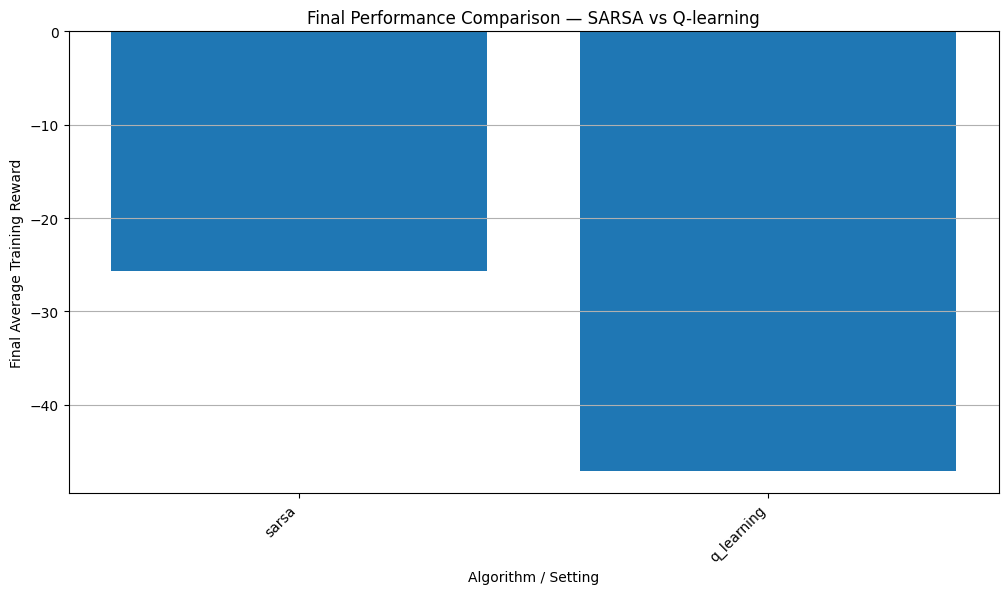

In [47]:
def plot_final_performance_bar(comparison_df, title):
    plt.figure(figsize=(12, 6))

    labels = comparison_df["Algorithm"].astype(str)
    values = comparison_df["Final Avg Train Reward"].values

    plt.bar(labels, values)

    plt.title(title)
    plt.xlabel("Algorithm / Setting")
    plt.ylabel("Final Average Training Reward")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y")
    plt.show()


plot_final_performance_bar(
    comparison_df,
    title="Final Performance Comparison — SARSA vs Q-learning"
)

### Exporting Comparison Tables

In [48]:
comparison_df.to_csv("table_1_sarsa_q_learning_comparison.csv", index=False)
alpha_comparison_df.to_csv("table_2_alpha_comparison.csv", index=False)
epsilon_comparison_df.to_csv("table_3_epsilon_schedule_comparison.csv", index=False)